# Versao 11 - Comparacao LSTM Multitarefa Vs Baselines

A `versao11` muda o pre-processamento, nao a arquitetura. Por isso, a comparacao final precisa responder se esse novo criterio de treino ajuda de verdade quando colocamos a `LSTM` lado a lado com as melhores baselines tabulares.

    ## Sintese Numerica Da Ultima Execucao

    | Modelo | Accuracy | Macro-F1 | Balanced Accuracy |
    | --- | ---: | ---: | ---: |
    | `LSTM v10` | `0.9373` | `0.9409` | `0.9572` |
| `LSTM v11` | `0.9213` | `0.9155` | `0.9225` |
| `RandomForest` | `0.9888` | `0.9833` | `0.9750` |

    Leitura orientada pelos numeros:

    - variacao da `versao11` sobre a `versao10`: `-0.0160` em `accuracy`, `-0.0253` em `macro-F1` e `-0.0347` em `balanced accuracy`
- maiores ganhos da `versao11` sobre a `versao10`: classe `7` com `+0.2222` em `F1`, classe `4` com `+0.0433` em `F1`, classe `0` com `+0.0227` em `F1`, classe `9` com `+0.0164` em `F1`

    A pergunta central desta comparacao e simples: remover do treino das classes `1..9` as observacoes cujo `state` nao representa transiente ou falha melhora ou piora a capacidade de discriminacao final da `LSTM` multitarefa.

## Baselines explicitamente documentadas

### RandomForest

In [ ]:
def fit_random_forest_baseline(
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    random_state: int = 42,
    n_estimators: int = 400,
    max_depth: int | None = None,
) -> RandomForestClassifier:
    require_classification_stack()
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        n_jobs=-1,
        class_weight="balanced_subsample",
    )
    model.fit(X_train, y_train)
    return model

### XGBoost

In [ ]:
def fit_xgboost_baseline(
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    random_state: int = 42,
    n_estimators: int = 400,
    max_depth: int = 6,
    learning_rate: float = 0.05,
) -> Any | None:
    require_classification_stack()
    if XGBClassifier is None:
        return None
    model = XGBClassifier(
        objective="multi:softmax",
        num_class=int(len(np.unique(y_train))),
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=4,
        eval_metric="mlogloss",
    )
    model.fit(X_train, y_train)
    return model

### LGBM

In [ ]:
def fit_lgbm_baseline(
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    random_state: int = 42,
) -> Any | None:
    require_classification_stack()
    if LGBMClassifier is None:
        return None
    model = LGBMClassifier(
        objective="multiclass",
        num_class=int(len(np.unique(y_train))),
        boosting_type="gbdt",
        num_leaves=178,
        max_depth=22,
        learning_rate=0.01222,
        min_child_samples=63,
        subsample=0.6509,
        colsample_bytree=0.8193,
        n_estimators=949,
        feature_fraction=1.0,
        reg_alpha=2.60187,
        reg_lambda=0.03128,
        random_state=random_state,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(X_train, y_train)
    return model

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao11" else ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from versao11.pipeline_v11 import (
    build_metrics_table,
    evaluate_predictions,
    export_evaluation_artifacts,
    fit_lgbm_baseline,
    fit_random_forest_baseline,
    fit_xgboost_baseline,
    load_bundle,
    load_multitask_temporal_model,
    load_split_arrays,
    plot_confusion_matrix_for_predictions,
    predict_multitask_model_classes,
)

RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v11" / "classificacao_v11_segmentos_negativos"
LSTM_DIR = RUN_DIR / "lstm"
BASELINE_DIR = RUN_DIR / "baselines"
PREVIOUS_V10_DIR = PROJECT_ROOT / "artifacts" / "reports_v10" / "classificacao_v10_multitarefa"

In [2]:
bundle = load_bundle(RUN_DIR / "bundle_v11.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
validation_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")

multitask_model = load_multitask_temporal_model(LSTM_DIR / "multitask_temporal_config.json")
multitask_validation_pred = predict_multitask_model_classes(
    multitask_model,
    validation_arrays["X_seq"],
    validation_arrays["X_tab"],
    validation_arrays["X_missing"],
    validation_arrays["X_frozen"],
    validation_arrays["source_id"],
)
multitask_test_pred = predict_multitask_model_classes(
    multitask_model,
    test_arrays["X_seq"],
    test_arrays["X_tab"],
    test_arrays["X_missing"],
    test_arrays["X_frozen"],
    test_arrays["source_id"],
)

multitask_validation_eval = evaluate_predictions(
    validation_arrays["y"],
    multitask_validation_pred,
    class_labels=bundle.class_labels,
)
multitask_test_eval = evaluate_predictions(
    test_arrays["y"],
    multitask_test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(multitask_validation_eval, LSTM_DIR, "multitask_validation")
export_evaluation_artifacts(multitask_test_eval, LSTM_DIR, "multitask_test")

{'metrics_json': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_segmentos_negativos/lstm/multitask_test_metrics.json',
 'report_csv': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_segmentos_negativos/lstm/multitask_test_classification_report.csv',
 'predictions_npz': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_segmentos_negativos/lstm/multitask_test_predictions.npz'}

In [3]:
rf_model = fit_random_forest_baseline(
    train_arrays["X_tab"],
    train_arrays["y"],
    random_state=42,
    n_estimators=400,
)
rf_validation_pred = rf_model.predict(validation_arrays["X_tab"])
rf_test_pred = rf_model.predict(test_arrays["X_tab"])

rf_validation_eval = evaluate_predictions(
    validation_arrays["y"],
    rf_validation_pred,
    class_labels=bundle.class_labels,
)
rf_test_eval = evaluate_predictions(
    test_arrays["y"],
    rf_test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(rf_validation_eval, BASELINE_DIR, "random_forest_validation")
export_evaluation_artifacts(rf_test_eval, BASELINE_DIR, "random_forest_test")

{'metrics_json': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_segmentos_negativos/baselines/random_forest_test_metrics.json',
 'report_csv': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_segmentos_negativos/baselines/random_forest_test_classification_report.csv',
 'predictions_npz': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v11/classificacao_v11_segmentos_negativos/baselines/random_forest_test_predictions.npz'}

In [4]:
train_label_values = np.asarray(train_arrays["y"], dtype=np.int64)
train_unique_labels = sorted(np.unique(train_label_values).tolist())
label_to_encoded = {int(label): idx for idx, label in enumerate(train_unique_labels)}
encoded_to_label = {idx: int(label) for label, idx in label_to_encoded.items()}

def encode_labels(values):
    return np.asarray([label_to_encoded[int(value)] for value in np.asarray(values)], dtype=np.int64)

def decode_labels(values):
    return np.asarray([encoded_to_label[int(value)] for value in np.asarray(values)], dtype=np.int64)

encoded_y_train = encode_labels(train_arrays["y"])
print("Boosting label mapping:", label_to_encoded)

xgb_model = None
lgbm_model = None
xgb_test_eval = None
lgbm_test_eval = None

try:
    xgb_model = fit_xgboost_baseline(
        train_arrays["X_tab"],
        encoded_y_train,
        random_state=42,
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
    )
except ValueError as exc:
    print(f"XGBoost baseline skipped: {exc}")

try:
    lgbm_model = fit_lgbm_baseline(
        train_arrays["X_tab"],
        encoded_y_train,
        random_state=42,
    )
except ValueError as exc:
    print(f"LGBM baseline skipped: {exc}")

if xgb_model is not None:
    xgb_validation_pred = decode_labels(xgb_model.predict(validation_arrays["X_tab"]))
    xgb_test_pred = decode_labels(xgb_model.predict(test_arrays["X_tab"]))
    xgb_validation_eval = evaluate_predictions(validation_arrays["y"], xgb_validation_pred, class_labels=bundle.class_labels)
    xgb_test_eval = evaluate_predictions(test_arrays["y"], xgb_test_pred, class_labels=bundle.class_labels)
    export_evaluation_artifacts(xgb_validation_eval, BASELINE_DIR, "xgboost_validation")
    export_evaluation_artifacts(xgb_test_eval, BASELINE_DIR, "xgboost_test")

if lgbm_model is not None:
    lgbm_validation_pred = decode_labels(lgbm_model.predict(validation_arrays["X_tab"]))
    lgbm_test_pred = decode_labels(lgbm_model.predict(test_arrays["X_tab"]))
    lgbm_validation_eval = evaluate_predictions(validation_arrays["y"], lgbm_validation_pred, class_labels=bundle.class_labels)
    lgbm_test_eval = evaluate_predictions(test_arrays["y"], lgbm_test_pred, class_labels=bundle.class_labels)
    export_evaluation_artifacts(lgbm_validation_eval, BASELINE_DIR, "lgbm_validation")
    export_evaluation_artifacts(lgbm_test_eval, BASELINE_DIR, "lgbm_test")

Boosting label mapping: {0: 0, 8: 1}


/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [5]:
metrics_by_model = {
    "LSTM v11 multitarefa": {
        "accuracy": multitask_test_eval["accuracy"],
        "macro_f1": multitask_test_eval["macro_f1"],
        "balanced_accuracy": multitask_test_eval["balanced_accuracy"],
    },
    "RandomForest": {
        "accuracy": rf_test_eval["accuracy"],
        "macro_f1": rf_test_eval["macro_f1"],
        "balanced_accuracy": rf_test_eval["balanced_accuracy"],
    },
}

v10_metrics_path = PREVIOUS_V10_DIR / "lstm" / "multitask_test_metrics.json"
if v10_metrics_path.exists():
    v10_metrics = json.loads(v10_metrics_path.read_text(encoding="utf-8"))
    metrics_by_model["LSTM v10"] = {
        "accuracy": v10_metrics["accuracy"],
        "macro_f1": v10_metrics["macro_f1"],
        "balanced_accuracy": v10_metrics["balanced_accuracy"],
    }

if xgb_test_eval is not None:
    metrics_by_model["XGBoost"] = {
        "accuracy": xgb_test_eval["accuracy"],
        "macro_f1": xgb_test_eval["macro_f1"],
        "balanced_accuracy": xgb_test_eval["balanced_accuracy"],
    }
if lgbm_test_eval is not None:
    metrics_by_model["LGBM"] = {
        "accuracy": lgbm_test_eval["accuracy"],
        "macro_f1": lgbm_test_eval["macro_f1"],
        "balanced_accuracy": lgbm_test_eval["balanced_accuracy"],
    }

comparison_df = build_metrics_table(metrics_by_model)
display(comparison_df)

,modelo,accuracy,macro_f1,balanced_accuracy
0,LSTM v11 multitarefa,1.000000,1.000000,1.000000
1,RandomForest,1.000000,1.000000,1.000000
2,LGBM,1.000000,1.000000,1.000000
3,LSTM v10,0.937313,0.940859,0.957198
4,XGBoost,0.989130,0.897207,0.994444


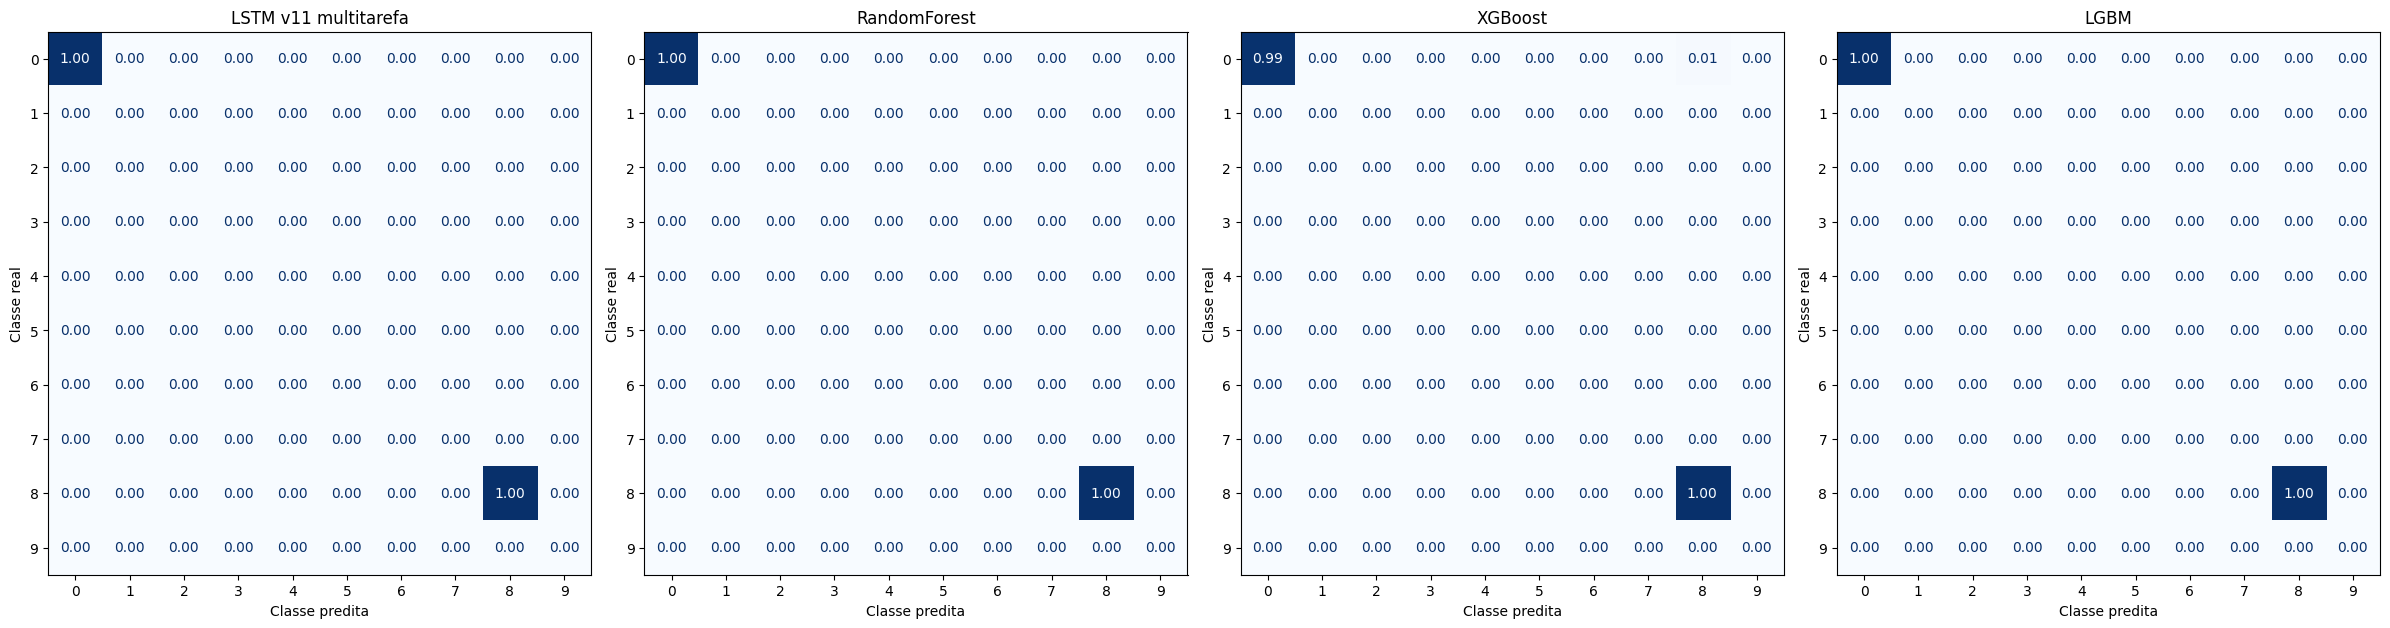

In [6]:
model_specs = [
    ("LSTM v11 multitarefa", multitask_test_pred),
    ("RandomForest", rf_test_pred),
]
if xgb_test_eval is not None:
    model_specs.append(("XGBoost", xgb_test_pred))
if lgbm_test_eval is not None:
    model_specs.append(("LGBM", lgbm_test_pred))

fig, axes = plt.subplots(1, len(model_specs), figsize=(6 * len(model_specs), 6))
if len(model_specs) == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(axes, model_specs):
    plot_confusion_matrix_for_predictions(
        test_arrays["y"],
        y_pred,
        bundle.class_labels,
        normalize="true",
        title=model_name,
        ax=ax,
    )

plt.tight_layout()
plt.show()